# **Import some needed libraries**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  
import plotly.express as px 
from sklearn.preprocessing import LabelEncoder , RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# **Load data and explore it**

In [2]:
df = pd.read_csv('egypt_yield_8400.csv')
df.head()

,crop,area_feddans,region,season,soil_type,yield_tonnes_per_feddan,production_tonnes
0,Fava Beans,167,Upper_Egypt,Winter,Sandy,3.840,641.3
1,Tomato,56,Delta,Nile,Calcareous,11.409,638.9
2,Tomato,2,North_Coast,Nile,Loamy,12.822,25.6
3,Rice,357,Delta,Summer,Loamy,3.309,1181.3
4,Cotton,178,NewLands,Summer,Sandy,0.903,160.7


In [29]:
df.shape

(8400, 7)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   crop                     8400 non-null   object 
 1   area_feddans             8400 non-null   int64  
 2   region                   8400 non-null   object 
 3   season                   8400 non-null   object 
 4   soil_type                8400 non-null   object 
 5   yield_tonnes_per_feddan  8400 non-null   float64
 6   production_tonnes        8400 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 459.5+ KB


In [31]:
df.duplicated().sum()

np.int64(1)

In [32]:
df.describe()

,area_feddans,yield_tonnes_per_feddan,production_tonnes
count,8400.000000,8400.000000,8400.000000
mean,272.524048,10.685971,3781.433369
std,243.787496,14.698584,8975.764201
min,1.000000,0.611000,1.000000
25%,94.000000,2.353500,318.700000
50%,185.000000,4.157500,908.200000
75%,393.000000,12.008250,2132.150000
max,999.000000,61.668860,61422.200000


In [33]:
num_col = df.select_dtypes(include=['int64','float64'])
print(num_col)

      area_feddans  yield_tonnes_per_feddan  production_tonnes
0              167                    3.840              641.3
1               56                   11.409              638.9
2                2                   12.822               25.6
3              357                    3.309             1181.3
4              178                    0.903              160.7
...            ...                      ...                ...
8395            63                   16.612             1046.6
8396            82                   16.814             1378.7
8397             6                   15.701               94.2
8398            18                    3.987               71.8
8399           189                    5.668             1071.3

[8400 rows x 3 columns]


In [34]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f'---- {col} ----')
    print(f'{col} outliers : {outlier} , lp = {lower_bound} , up = {upper_bound}')
    print('---'*20)

---- area_feddans ----
area_feddans outliers : 328 , lp = -354.5 , up = 841.5
------------------------------------------------------------
---- yield_tonnes_per_feddan ----
yield_tonnes_per_feddan outliers : 1000 , lp = -12.128625 , up = 26.490375
------------------------------------------------------------
---- production_tonnes ----
production_tonnes outliers : 904 , lp = -2401.4750000000004 , up = 4852.325000000001
------------------------------------------------------------


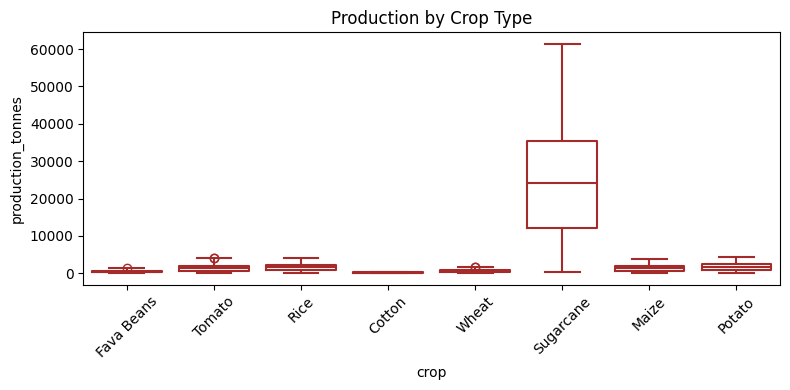

In [35]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='crop', y='production_tonnes', data=df,fill=False,color='brown')
sns.color_palette("dark:#5A9_r", as_cmap=True)
plt.xticks(rotation=45)
plt.title('Production by Crop Type')
plt.tight_layout()
plt.show()

In [36]:
df.groupby('crop')['production_tonnes'].describe()

,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
Cotton,1000.0,157.762200,97.161531,1.0,79.200,145.70,227.575,436.6
Fava Beans,1000.0,475.247200,304.651457,3.7,218.900,453.35,697.725,1489.5
Maize,1100.0,1399.202000,869.187006,2.7,670.700,1329.90,2060.050,3935.3
Potato,1000.0,1671.004800,990.411450,11.6,832.125,1638.15,2386.050,4469.4
Rice,1000.0,1624.408900,975.101981,2.9,805.550,1599.85,2344.625,4076.1
Sugarcane,1000.0,24114.105900,14189.546679,280.9,12126.350,24073.65,35361.550,61422.2
Tomato,1100.0,1372.972000,876.513069,7.0,626.075,1292.50,1998.650,4185.7
Wheat,1200.0,560.099917,353.332545,1.5,276.475,515.35,810.925,1739.5


In [37]:
outliers_df = df[df['production_tonnes'] > upper_bound]

print((outliers_df.head(10)))

         crop  area_feddans       region  season soil_type  \
14  Sugarcane           693  Upper_Egypt  Summer     Sandy   
22  Sugarcane           588     NewLands    Nile      Clay   
35  Sugarcane           592     NewLands    Nile      Clay   
37  Sugarcane           701  Upper_Egypt  Summer     Loamy   
54  Sugarcane           377     NewLands  Summer     Sandy   
63  Sugarcane           899  Upper_Egypt  Summer      Clay   
64  Sugarcane           458  Upper_Egypt    Nile      Clay   
69  Sugarcane           920  Upper_Egypt    Nile      Clay   
80  Sugarcane           504  Upper_Egypt    Nile      Clay   
92  Sugarcane           488     NewLands  Summer     Loamy   

    yield_tonnes_per_feddan  production_tonnes  
14                   40.999            28412.3  
22                   42.694            25104.1  
35                   43.236            25595.7  
37                   58.513            41017.6  
54                   40.333            15205.5  
63                   40

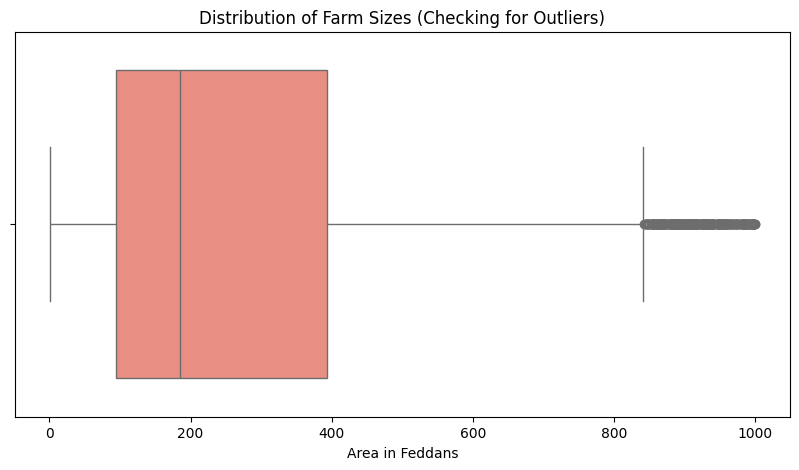

In [38]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['area_feddans'], color='salmon')
plt.title('Distribution of Farm Sizes (Checking for Outliers)')
plt.xlabel('Area in Feddans')
plt.show()

C:\Users\ramez\AppData\Local\Temp\ipykernel_11876\3512150918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='crop', y='yield_tonnes_per_feddan', data=df, order=order, palette='viridis')


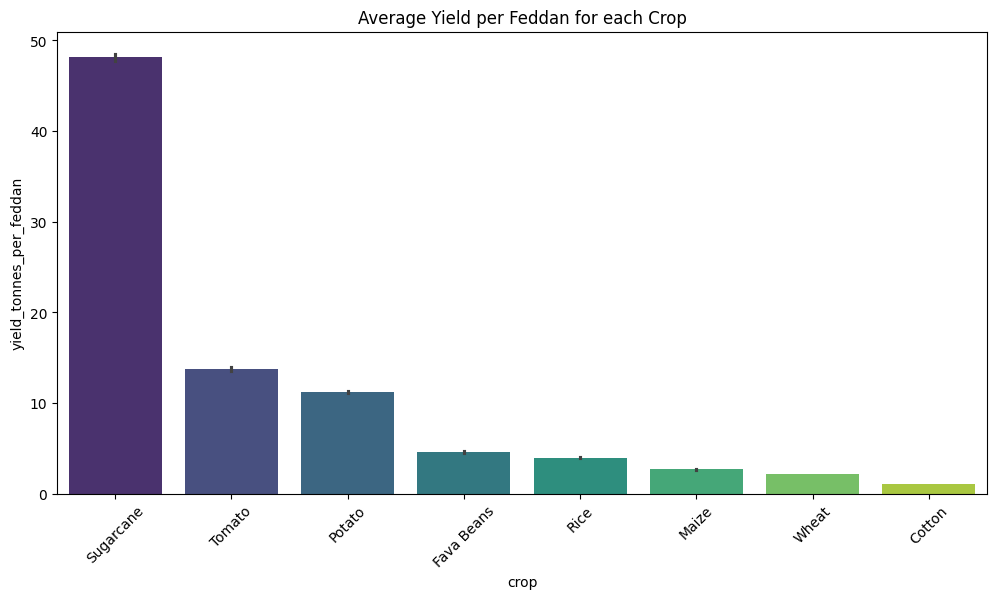

In [39]:
plt.figure(figsize=(12, 6))
order = df.groupby('crop')['yield_tonnes_per_feddan'].mean().sort_values(ascending=False).index

sns.barplot(x='crop', y='yield_tonnes_per_feddan', data=df, order=order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Yield per Feddan for each Crop')
plt.show()

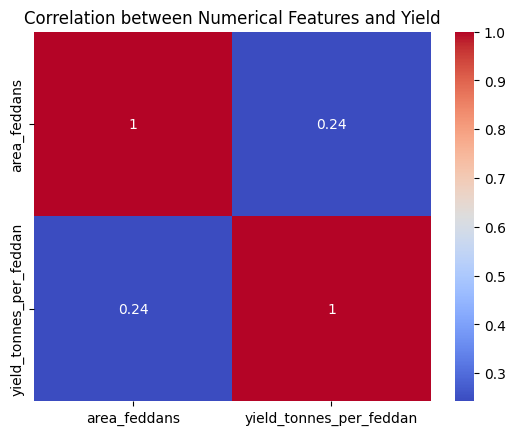

In [40]:
correlation_matrix = df[['area_feddans', 'yield_tonnes_per_feddan']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Numerical Features and Yield')
plt.show()

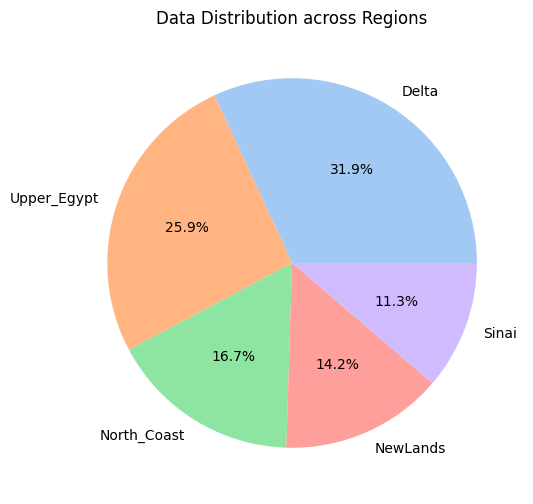

In [41]:
plt.figure(figsize=(10, 6))
df['region'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Data Distribution across Regions')
plt.ylabel('')
plt.show()

# **Encoding Categorical Features**

In [42]:
crop_map = {"Wheat": 0, "Rice": 1, "Maize": 2, "Cotton": 3, "Sugarcane": 4, "Tomato": 5, "Potato": 6, "Fava Beans": 7}
soil_map = {"Clay": 0, "Loamy": 1, "Calcareous": 2, "Sandy": 3}
region_map = {"Delta": 0, "Upper_Egypt": 1, "North_Coast": 2, "Sinai": 3, "NewLands": 4}
season_map = {"Winter": 0, "Summer": 1, "Nile": 2}

df['soil_type'] = df['soil_type'].map(soil_map)
df['region'] = df['region'].map(region_map)
df['season'] = df['season'].map(season_map)
df['crop'] = df['crop'].map(crop_map)

In [43]:
print(df[['soil_type', 'region', 'season', 'crop']].isnull().sum())

soil_type    0
region       0
season       0
crop         0
dtype: int64


In [44]:
df.head()

,crop,area_feddans,region,season,soil_type,yield_tonnes_per_feddan,production_tonnes
0,7,167,1,0,3,3.840,641.3
1,5,56,0,2,2,11.409,638.9
2,5,2,2,2,1,12.822,25.6
3,1,357,0,1,1,3.309,1181.3
4,3,178,4,1,3,0.903,160.7


# **Data Split**

In [45]:
x = df.drop(['production_tonnes','yield_tonnes_per_feddan'], axis=1)
y = df['yield_tonnes_per_feddan']

In [46]:
x

,crop,area_feddans,region,season,soil_type
0,7,167,1,0,3
1,5,56,0,2,2
2,5,2,2,2,1
3,1,357,0,1,1
4,3,178,4,1,3
...,...,...,...,...,...
8395,5,63,3,2,0
8396,5,82,2,2,0
8397,5,6,2,1,1
8398,7,18,1,0,2


In [47]:
y

0        3.840
1       11.409
2       12.822
3        3.309
4        0.903
         ...  
8395    16.612
8396    16.814
8397    15.701
8398     3.987
8399     5.668
Name: yield_tonnes_per_feddan, Length: 8400, dtype: float64

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6720, 5)
(1680, 5)
(6720,)
(1680,)


# **ModeeeeeL**

In [49]:
# Parameters to balance Overfitting/Underfitting
param_dist = {
    'n_estimators': [500, 700],
    'max_depth': [1,4,8,15,None],
    'min_samples_split': [2, 5, 10],    
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2'],
    }

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = RandomizedSearchCV(
    rf_base,
    param_dist,
    n_iter=100,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,
    verbose=1
)

print('Running hyperparameter tuning...')
grid_search.fit(x_train, y_train)

print(f'\nBest parameters:')
for param, value in grid_search.best_params_.items():
    print(f'  • {param}: {value}')
print(f'\nBest CV R² Score: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
print("Train R²:", round(best_rf.score(x_train, y_train), 4))
print("Test R²:",  round(best_rf.score(x_test,  y_test),  4))

Running hyperparameter tuning...
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best parameters:
  • n_estimators: 500
  • min_samples_split: 10
  • min_samples_leaf: 2
  • max_features: sqrt
  • max_depth: 15

Best CV R² Score: 0.9706
Train R²: 0.9822
Test R²: 0.9709


In [50]:
best_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(x_train, y_train)
print('✓ Final model trained')

✓ Final model trained


# **Evaluation**

In [51]:
# Predictions
y_train_pred = best_rf.predict(x_train)
y_test_pred = best_rf.predict(x_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('='*80)
print('RESULTS')
print('='*80)
print(f'\nTRAINING:')
print(f'  R² Score: {train_r2:.4f}')
print(f'  MAE: {train_mae:.4f} tonnes/feddan')
print(f'  RMSE: {train_rmse:.4f} tonnes/feddan')

print(f'\nTEST (Honest Evaluation):')
print(f'  R² Score: {test_r2:.4f}')
print(f'  MAE: {test_mae:.4f} tonnes/feddan')
print(f'  RMSE: {test_rmse:.4f} tonnes/feddan')

# Check for Overfitting
gap = train_r2 - test_r2
print(f'\nOVERFITTING CHECK:')
print(f'  Train-Test Gap: {gap:.4f}')
if gap > 0.1:
    print(f'Possible Overfitting')
elif gap < -0.05:
    print(f'Possible Underfitting')
else:
    print(f'Good Balance')

RESULTS

TRAINING:
  R² Score: 0.9822
  MAE: 1.1019 tonnes/feddan
  RMSE: 1.9622 tonnes/feddan

TEST (Honest Evaluation):
  R² Score: 0.9709
  MAE: 1.3778 tonnes/feddan
  RMSE: 2.5046 tonnes/feddan

OVERFITTING CHECK:
  Train-Test Gap: 0.0113
Good Balance


In [52]:
cv_scores = cross_val_score(best_rf, x_train, y_train, cv=5, scoring='r2')

print('5-Fold Cross-Validation:')
print(f'  Scores: {[f"{score:.4f}" for score in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'  Stable: {"YES" if cv_scores.std() < 0.05 else "Check"}')

5-Fold Cross-Validation:
  Scores: ['0.9679', '0.9691', '0.9693', '0.9725', '0.9733']
  Mean: 0.9704 (+/- 0.0021)
  Stable: YES


In [53]:
df.columns

Index(['crop', 'area_feddans', 'region', 'season', 'soil_type',
       'yield_tonnes_per_feddan', 'production_tonnes'],
      dtype='object')

Top 10 Important Features:
  crop                           0.7101
  area_feddans                   0.1460
  season                         0.0685
  region                         0.0602
  soil_type                      0.0151


C:\Users\ramez\AppData\Local\Temp\ipykernel_11876\382685052.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


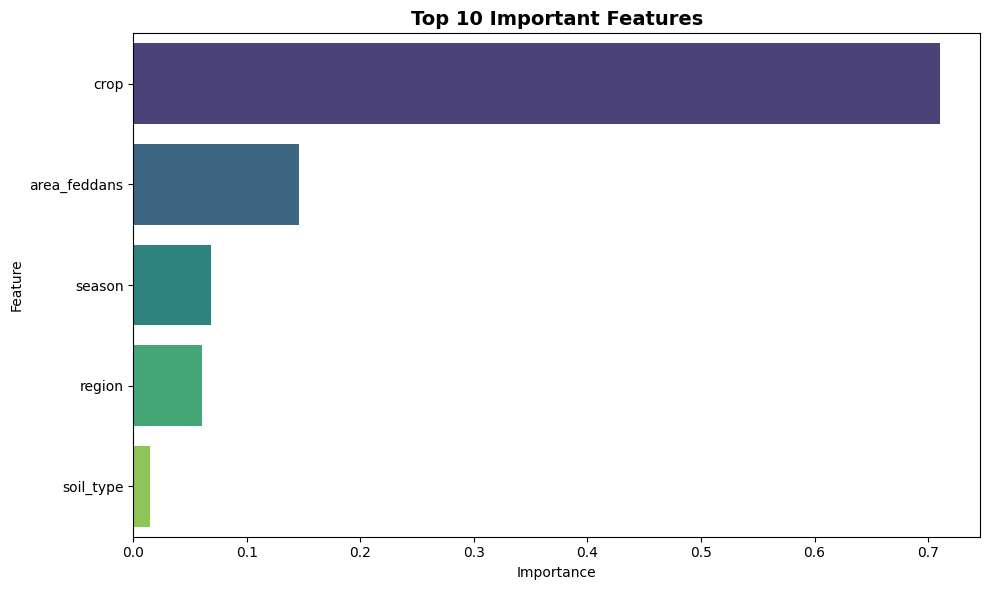

In [54]:
feature_names = ['crop', 'area_feddans', 'region','season', 'soil_type']

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 10 Important Features:')
for idx, row in feature_importance_df.head(10).iterrows():
    print(f'  {row["Feature"]:<30} {row["Importance"]:.4f}')

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
print("Yield for 10 Feddans:", best_rf.predict([[4, 10, 0, 2, 1]]))
print("Yield for 50 Feddans:", best_rf.predict([[4, 50, 0, 2, 1]]))

Yield for 10 Feddans: [30.6735858]
Yield for 50 Feddans: [30.47417084]


C:\Users\ramez\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ramez\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# **Save Model**

In [61]:
import joblib

joblib.dump({
    'model':      best_rf,
    'crop_map':   crop_map,
    'region_map': region_map,
    'season_map': season_map,
    'soil_map':   soil_map,
    'features':   x.columns.tolist(),
    'avg_yield': {
        'Wheat': 2.2, 'Maize': 2.7, 'Rice': 3.9,
        'Cotton': 1.1, 'Sugarcane': 48.0, 'Tomato': 13.7,
        'Potato': 11.2, 'Fava Beans': 4.6
    }
}, 'yield_model.pkl')

print("Saved!")

Saved!
